In [ ]:
# import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from scipy.stats import zscore
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import (
    #MinMaxScaler,
    RobustScaler,
    # StandardScaler
)
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torchvision import transforms

from packages.anfis.anfis import AnfisNet
from packages.anfis.cmeans import cmeans_cluster
from packages.anfis.experimental import train_anfis_with
from packages.anfis.membership import make_gauss_mfs
from packages.loader import CropsDataset
from packages.plots.plots_data import plot_class_distribution, plot_subset_distribution
from packages.plots.plots_images import plot_random_samples
from packages.transformers import (
    #CLAHETransform,
    QuantizeLevelsTransform,
    ToGrayscalePIL,
    # WhiteTopHatTransform,
)
from packages.utils import (
    check_if_numpy_data_exists,
    dataset_to_dataframe,
    load_all_numpy_data,
    save_all_numpy_data,
)

# Classificação de Segmentos de Artérias

## Carregar dados

### Carregar DataFrame com informações do dataset

In [2]:
df = pd.read_csv('../output/classification_annotations_reshuffled.csv')

# Verificar se a coluna existe
assert 'crop_path' in df.columns, "A coluna 'crop_path' não existe no DataFrame."
assert 'subset' in df.columns, "A coluna 'subset' não existe no DataFrame."

# Separar por subset
df_train = df[df['subset'] == 'train'].reset_index(drop=True)
df_val = df[df['subset'] == 'val'].reset_index(drop=True)
df_test = df[df['subset'] == 'test'].reset_index(drop=True)

print(f"Total: {len(df)} amostras")
print(f"Train: {len(df_train)} amostras")
print(f"Val: {len(df_val)} amostras")
print(f"Test: {len(df_test)} amostras")

df.head()

Total: 10233 amostras
Train: 6139 amostras
Val: 2047 amostras
Test: 2047 amostras


,id,image_id,category_id,segmentation,area,bbox,iscrowd,attributes,set_type,label,crop_path,subset
0,246,472,26,"[[84.44, 112.5, 81.75, 118.25, 81.1, 125.7, 80...",1362.0,"[53.88, 112.5, 46.18, 91.0]",0,{'occluded': False},stenosis,1,../output/crops/train/472_1310.png,train
1,111,53,26,"[[188.88, 94.5, 189.75, 78.25, 194.38, 78.25, ...",1678.0,"[188.88, 78.17, 108.87, 48.33]",0,{'occluded': False},stenosis,1,../output/crops/val/53_1735.png,train
2,3619,540,11,"[[307.25, 269.5, 314.0, 271.5, 321.25, 274.75,...",692.0,"[303.5, 262.0, 136.5, 71.0]",0,{'occluded': False},syntax,0,../output/crops/train/540_6035.png,train
3,3469,117,6,"[[259.5, 94.38, 267.5, 92.88, 265.75, 87.5, 26...",918.0,"[183.62, 27.8, 83.88, 66.58]",0,{'occluded': False},syntax,0,../output/crops/train/117_5885.png,train
4,178,33,5,"[[212.9, 100.91, 216.25, 98.85, 220.37, 97.3, ...",783.0,"[202.6, 76.04, 59.88, 39.03]",0,{'occluded': False},syntax,0,../output/crops/test/33_8738.png,train


### Carregar imagens crops e extrair características GLCM

In [3]:
# Criar datasets separados
glcm_cfg = {
    'enabled': True,
    'distances': [1],
    'angles': [0, np.pi/4, np.pi/2, 3*np.pi/4], # 0°, 45°, 90°, 135°
    'levels': 256,
    'features': ['contrast','dissimilarity','homogeneity','energy','correlation','ASM']
}

# Definir transformações
train_tf = transforms.Compose([
    ToGrayscalePIL(),
    #WhiteTopHatTransform(kernel_size=15),
    #CLAHETransform(clip_limit=2.0, tile_grid_size=(8,8)),
    QuantizeLevelsTransform(levels=glcm_cfg['levels']),
])

# Criar datasets
ds_train = CropsDataset(df_train, transform=train_tf, glcm_cfg=glcm_cfg, return_mode='features')
ds_val = CropsDataset(df_val, transform=train_tf, glcm_cfg=glcm_cfg, return_mode='features')
ds_test = CropsDataset(df_test, transform=train_tf, glcm_cfg=glcm_cfg, return_mode='features')

# Converter datasets em dataframes e arrays numpy
if not check_if_numpy_data_exists('../output/cache_data'):
    df_train_feats, X_train, y_train = dataset_to_dataframe(ds_train, glcm_cfg['features'], return_xy=True)
    df_val_feats, X_val, y_val = dataset_to_dataframe(ds_val, glcm_cfg['features'], return_xy=True)
    df_test_feats, X_test, y_test = dataset_to_dataframe(ds_test, glcm_cfg['features'], return_xy=True)

    save_all_numpy_data('../output/cache_data', X_train, y_train, X_val, y_val, X_test, y_test)
    df_train_feats.to_csv('../output/cache_data/df_train_feats.csv', index=False)
    df_val_feats.to_csv('../output/cache_data/df_val_feats.csv', index=False)
    df_test_feats.to_csv('../output/cache_data/df_test_feats.csv', index=False)
else:
    X_train, y_train, X_val, y_val, X_test, y_test = load_all_numpy_data('../output/cache_data')
    df_train_feats = pd.read_csv('../output/cache_data/df_train_feats.csv')
    df_val_feats = pd.read_csv('../output/cache_data/df_val_feats.csv')
    df_test_feats = pd.read_csv('../output/cache_data/df_test_feats.csv')

df_concats = pd.concat([df_train_feats, df_val_feats, df_test_feats], ignore_index=True)
df_concats.head()

,contrast,dissimilarity,homogeneity,energy,correlation,ASM,label
0,33.743767,4.040420,0.254050,0.036955,0.955256,0.001372,1
1,36.648331,4.517629,0.213363,0.038586,0.885801,0.001502,1
2,39.944965,4.911728,0.187241,0.040665,0.773671,0.001655,0
3,60.137787,5.667423,0.191279,0.049231,0.913868,0.002431,0
4,24.963030,3.793067,0.254812,0.069863,0.970032,0.004901,0


## Analise exploratória dos dados (EDA)

### Visualizar amostras

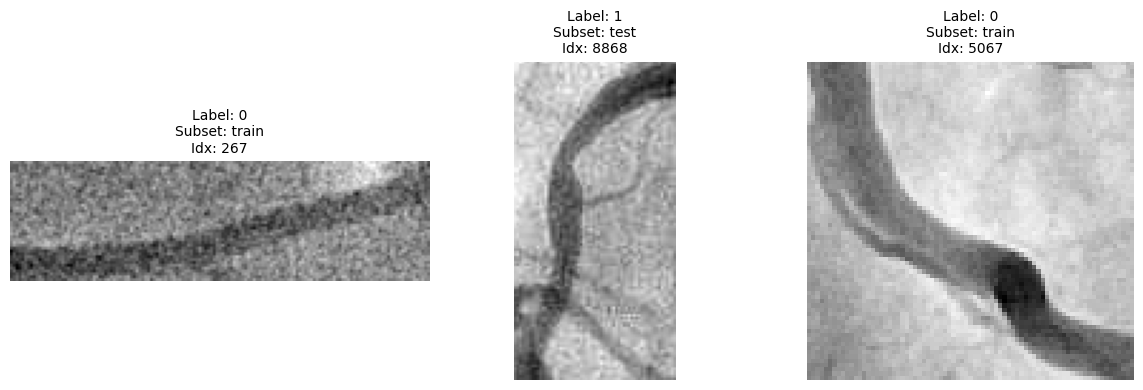

In [4]:
# Plotar amostras aleatórias
fig, axes = plot_random_samples(df, n_samples=3)

### Distribuição das classes

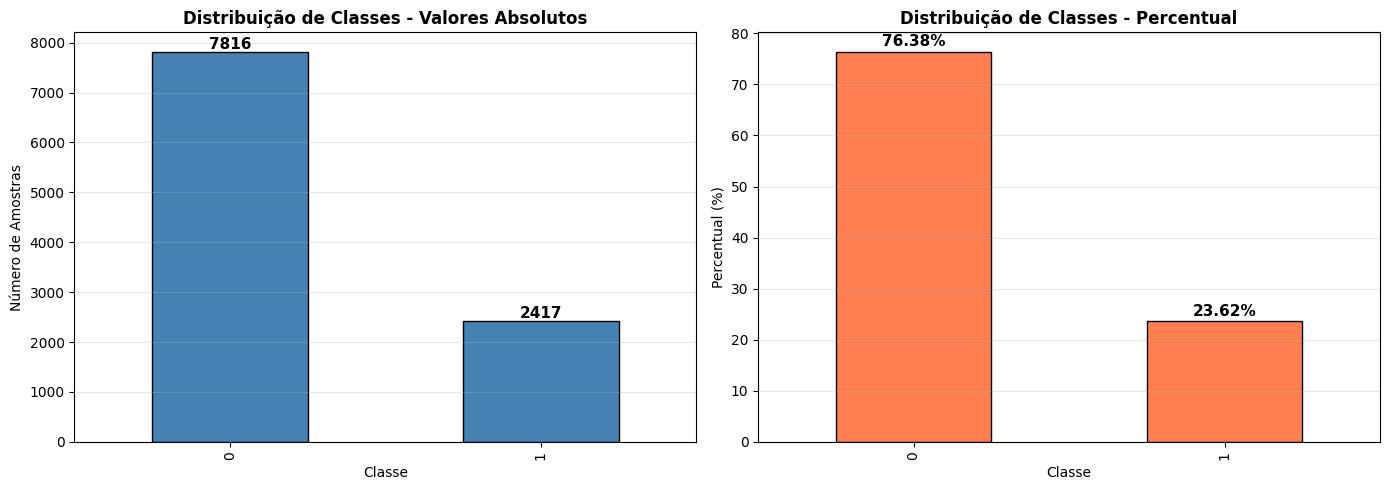

In [5]:
# Visualização da distribuição geral
fig, axes = plot_class_distribution(df)

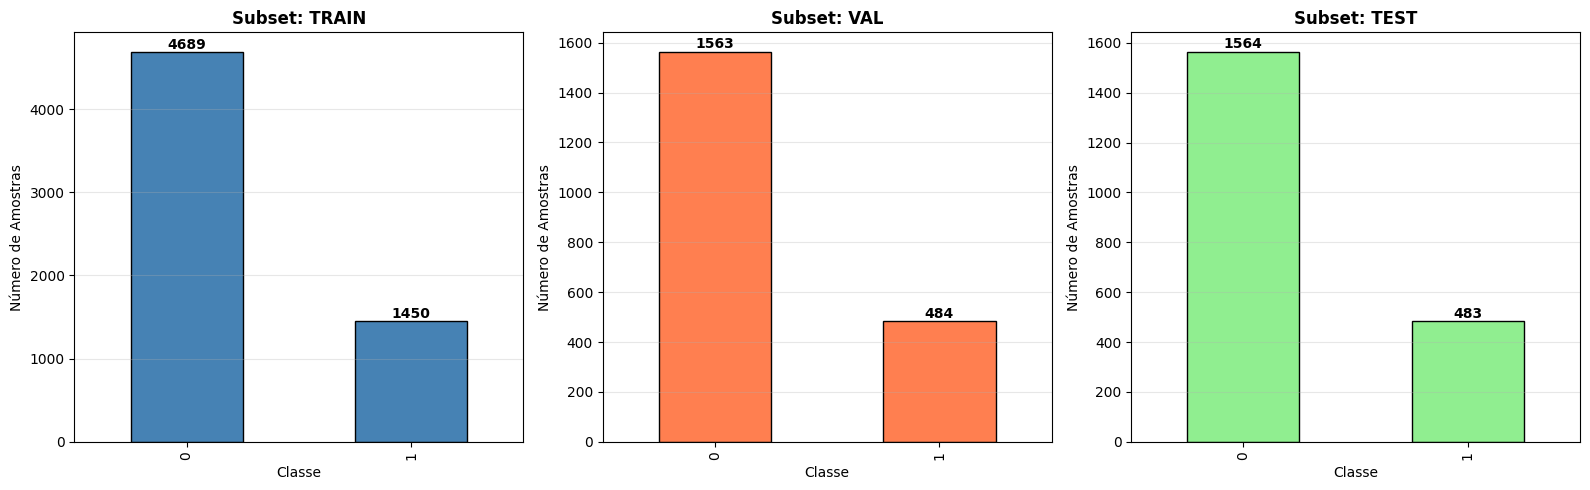

In [6]:
# Visualização por subset
fig, axes = plot_subset_distribution(df)

### Visualizar estatísticas das características GLCM

In [7]:
# Estatísticas por feature
df_concats.describe()

,contrast,dissimilarity,homogeneity,energy,correlation,ASM,label
count,10233.000000,10233.000000,10233.000000,10233.000000,10233.000000,10233.000000,10233.000000
mean,45.259930,4.662955,0.230501,0.053305,0.897677,0.003605,0.236197
std,34.880058,1.417563,0.064336,0.027462,0.088526,0.005016,0.424765
min,2.855182,1.200509,0.088518,0.017308,0.169005,0.000301,0.000000
25%,25.652348,3.766784,0.186826,0.033078,0.873659,0.001097,0.000000
50%,38.183800,4.643449,0.210481,0.045031,0.924136,0.002038,0.000000
75%,54.725082,5.452781,0.258636,0.065969,0.952845,0.004361,0.000000
max,655.455811,16.247982,0.628582,0.532327,0.998048,0.283422,1.000000


In [8]:
# Estatísticas agrupadas por label
print(glcm_cfg['features'])
print(df_concats.columns)
df_concats.groupby('label')[glcm_cfg['features']].aggregate(['mean', 'std'])

['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
Index(['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation',
       'ASM', 'label'],
      dtype='object')


contrast            dissimilarity           homogeneity            \
            mean        std          mean       std        mean       std   
label                                                                       
0      46.468853  35.168686      4.730967  1.424473    0.227899  0.065281   
1      41.350563  33.640823      4.443020  1.372381    0.238915  0.060431   

         energy           correlation                 ASM            
           mean       std        mean       std      mean       std  
label                                                                
0      0.054638  0.027979    0.897455  0.089574  0.003777  0.004338  
1      0.048995  0.025247    0.898397  0.085062  0.003048  0.006729

In [9]:
# Estatísticas agrupadas por label
df_concats.groupby('label')[glcm_cfg['features']].aggregate(['min', 'max'])

contrast             dissimilarity            homogeneity            \
            min         max           min        max         min       max   
label                                                                        
0      3.452631  655.455811      1.308800  16.062050    0.102827  0.539203   
1      2.855182  622.092407      1.200509  16.247982    0.088518  0.628582   

         energy           correlation                 ASM            
            min       max         min       max       min       max  
label                                                                
0      0.017308  0.294358    0.169005  0.998048  0.000301  0.086660  
1      0.020583  0.532327    0.373360  0.997639  0.000424  0.283422

### Visualizar distribuição dos dados

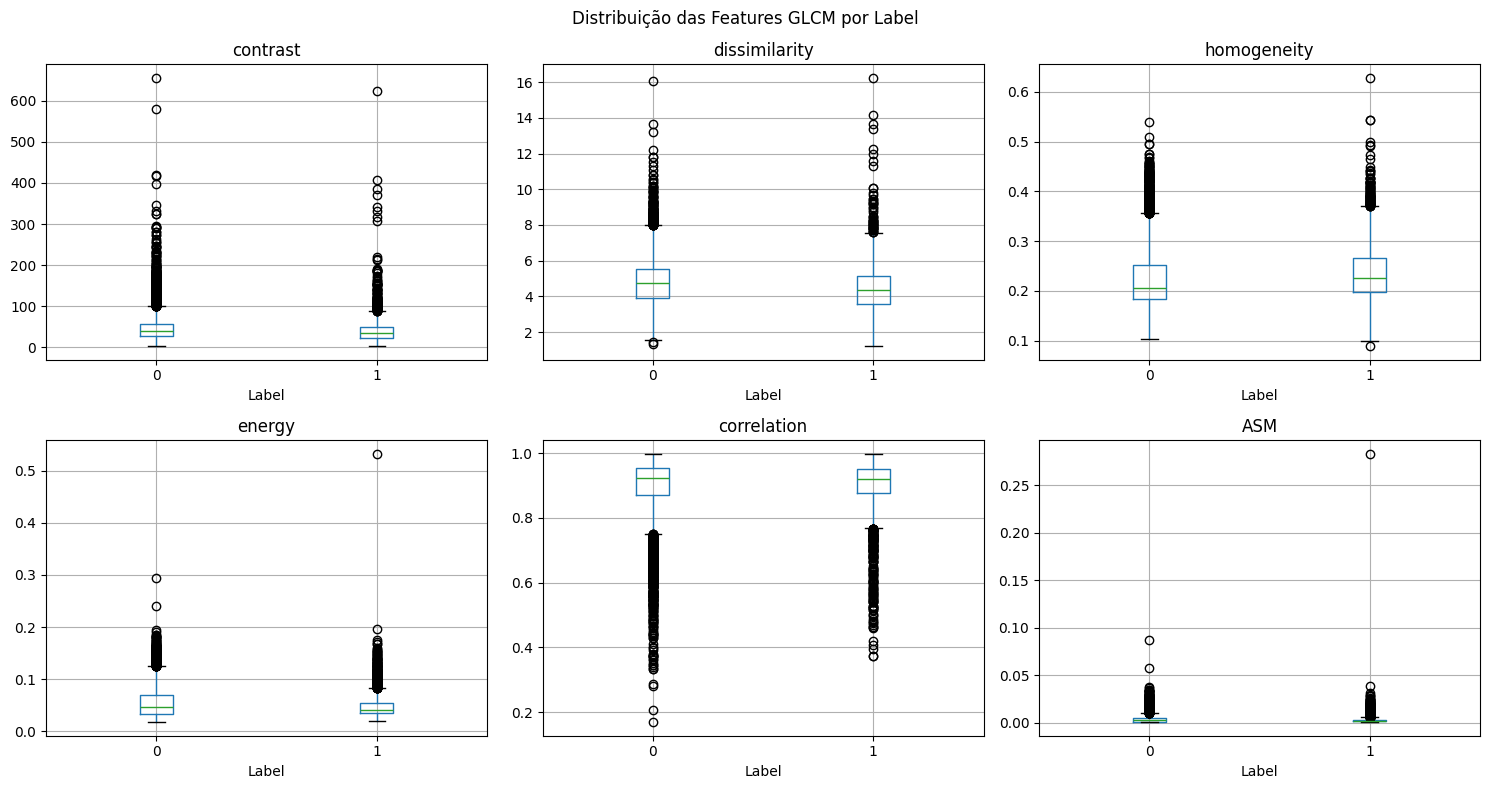

In [10]:
# Boxplot de cada feature por label
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(glcm_cfg['features']):
    df_concats.boxplot(column=feat, by='label', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel('Label')

plt.suptitle('Distribuição das Features GLCM por Label')
plt.tight_layout()
plt.show()

### Visualizar correlações entre características

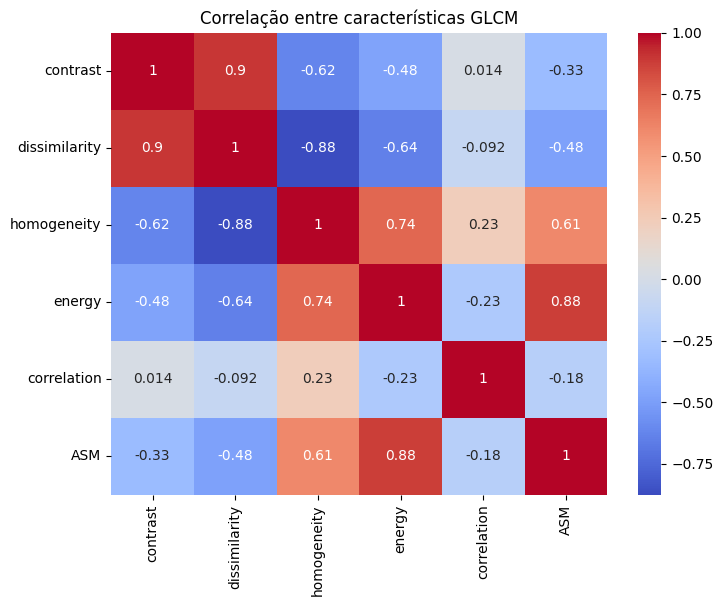

In [11]:
corr = df_concats[glcm_cfg['features']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlação entre características GLCM')
plt.show()

## Pré-processamento

### Remover features altamente correlacionadas

In [12]:
# Calcule a matriz de correlação
corr_matrix = pd.DataFrame(X_train, columns=glcm_cfg['features']).corr().abs()

# Encontrar features com alta correlação
threshold = 0.9
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

# Remova as colunas dos arrays
keep_idx = [i for i, f in enumerate(glcm_cfg['features']) if f not in to_drop]
X_train_reduced = X_train[:, keep_idx]
X_val_reduced = X_val[:, keep_idx]
X_test_reduced = X_test[:, keep_idx]

# Atualize a lista de features se necessário
features_reduced = [glcm_cfg['features'][i] for i in keep_idx]
print("Features mantidas após remoção de alta correlação:", features_reduced)

X_train_reduced = X_train
X_val_reduced = X_val
X_test_reduced = X_test
X_train_reduced.shape, X_val_reduced.shape, X_test_reduced.shape
features_reduced = glcm_cfg['features']

Features mantidas após remoção de alta correlação: ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']


### Remover Outliers

In [13]:
# Calcule o z-score para o conjunto de treino
z_scores_train = np.abs(zscore(X_train_reduced, axis=0))
threshold = 3
mask_train = (z_scores_train < threshold).all(axis=1)
X_train_no_outliers = X_train_reduced[mask_train]
y_train_no_outliers = y_train[mask_train]

# Calcular média e desvio padrão do conjunto de treino
mean = X_train_reduced.mean(axis=0)
std = X_train_reduced.std(axis=0)

# Aplicar a mesma máscara para validação e teste
z_scores_val = np.abs((X_val_reduced - mean) / std)
mask_val = (z_scores_val < threshold).all(axis=1)
X_val_no_outliers = X_val_reduced[mask_val]
y_val_no_outliers = y_val[mask_val]

z_scores_test = np.abs((X_test_reduced - mean) / std)
mask_test = (z_scores_test < threshold).all(axis=1)
X_test_no_outliers = X_test_reduced[mask_test]
y_test_no_outliers = y_test[mask_test]

print(f"Treino com outliers: {X_train_reduced.shape[0]} amostras")
print(f"Treino sem outliers: {X_train_no_outliers.shape[0]} amostras")

print(f"Validação com outliers: {X_val_reduced.shape[0]} amostras")
print(f"Validação sem outliers: {X_val_no_outliers.shape[0]} amostras")

print(f"Teste com outliers: {X_test_reduced.shape[0]} amostras")
print(f"Teste sem outliers: {X_test_no_outliers.shape[0]} amostras")

X_train_no_outliers = X_train_reduced
y_train_no_outliers = y_train
X_val_no_outliers = X_val_reduced
y_val_no_outliers = y_val
X_test_no_outliers = X_test_reduced
y_test_no_outliers = y_test

Treino com outliers: 6139 amostras
Treino sem outliers: 5776 amostras
Validação com outliers: 2047 amostras
Validação sem outliers: 1922 amostras
Teste com outliers: 2047 amostras
Teste sem outliers: 1926 amostras


Total de outliers no treino: 363


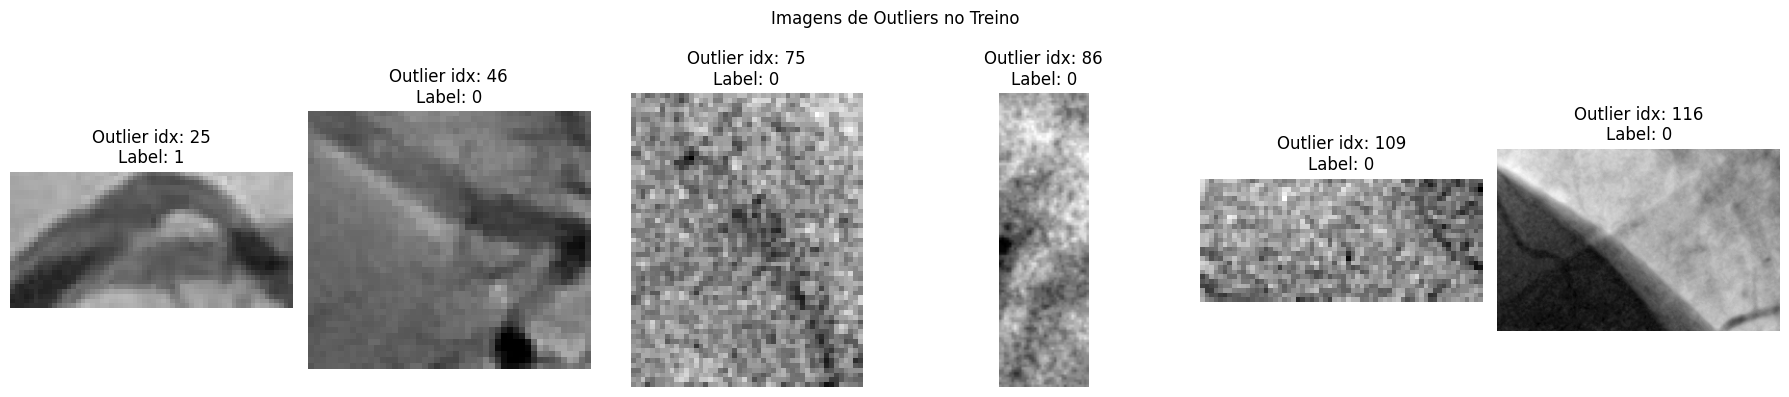

In [14]:
outlier_indices = np.where(~mask_train)[0]

print(f"Total de outliers no treino: {len(outlier_indices)}")

n_show = min(6, len(outlier_indices))
fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 4))

for i, idx in enumerate(outlier_indices[:n_show]):
    crop_path = df_train.iloc[idx]['crop_path']
    img = Image.open(crop_path)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Outlier idx: {idx}\nLabel: {df_train.iloc[idx]['label']}")
    axes[i].axis('off')

plt.suptitle("Imagens de Outliers no Treino")
plt.tight_layout()
plt.show()

### Normalizar os dados

In [15]:
# Normalizar features
scaler = RobustScaler()
# scaler = StandardScaler()
# scaler = MinMaxScaler((0, 1))
X_train_scaled = scaler.fit_transform(X_train_no_outliers)
X_val_scaled = scaler.transform(X_val_no_outliers)
X_test_scaled = scaler.transform(X_test_no_outliers)

print("Min-Max após normalização:")
print(f"Train: min={X_train_scaled.min()}, max={X_train_scaled.max()}")
print(f"Val: min={X_val_scaled.min()}, max={X_val_scaled.max()}")
print(f"Test: min={X_test_scaled.min()}, max={X_test_scaled.max()}")

Min-Max após normalização:
Train: min=-9.838183403015137, max=88.12194061279297
Val: min=-7.552014350891113, max=17.36097526550293
Test: min=-7.176944255828857, max=12.505416870117188


### Criar os Dataloaders

In [16]:
# Converter para tensores PyTorch
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float64)
y_train_t = torch.tensor(y_train_no_outliers, dtype=torch.long)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float64)
y_val_t = torch.tensor(y_val_no_outliers, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float64)
y_test_t = torch.tensor(y_test_no_outliers, dtype=torch.long)

USE_BINARY = False

if USE_BINARY:
    num_outputs = 1
    y_train_ds = y_train_t.unsqueeze(1).to(torch.float64)
    y_val_ds = y_val_t.unsqueeze(1).to(torch.float64)
    y_test_ds = y_test_t.unsqueeze(1).to(torch.float64)
else:
    num_outputs = 2
    y_train_ds = torch.nn.functional.one_hot(y_train_t, num_classes=num_outputs).to(torch.float64)
    y_val_ds = torch.nn.functional.one_hot(y_val_t, num_classes=num_outputs).to(torch.float64)
    y_test_ds = torch.nn.functional.one_hot(y_test_t, num_classes=num_outputs).to(torch.float64)

# Criar TensorDataset e DataLoader
batch_size = 32

train_ds = TensorDataset(X_train_t, y_train_ds)
val_ds = TensorDataset(X_val_t, y_val_ds)
test_ds = TensorDataset(X_test_t, y_test_ds)

# Calcular pesos das classes
class_counts = np.bincount(y_train_no_outliers)
class_weights = torch.tensor(class_counts.max() / class_counts, dtype=torch.float64)

print(f"Distribuição de classes: {class_counts}")
print(f"Pesos das classes: {class_weights}")

# Criar os samples para balancear
sample_weights = [class_weights[label] for label in y_train_no_outliers]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print("\nDataLoaders criados:")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Distribuição de classes: [4689 1450]
Pesos das classes: tensor([1.0000, 3.2338], dtype=torch.float64)

DataLoaders criados:
Train batches: 192
Val batches: 64
Test batches: 64


## Treinamento

In [17]:
# Parâmetros do modelo
num_mfs = 2  # funções de pertinência por entrada

# Criar definições de MFs para cada entrada usando os nomes das features GLCM
invardefs = []
minvals, _ = torch.min(X_train_t, dim=0)
maxvals, _ = torch.max(X_train_t, dim=0)
ranges = maxvals - minvals

""" # Definir MFs gaussianas para cada feature (Grid-Partitioning)
for i, feature_name in enumerate(features_reduced):
    sigma = ranges[i] / num_mfs
    mulist = torch.linspace(minvals[i], maxvals[i], num_mfs).tolist()
    mfs = make_gauss_mfs(sigma, mulist)
    invardefs.append((feature_name, mfs))
"""

# Parâmetros: a (largura), b (inclinação), c (centro)
""" for i, feature_name in enumerate(features_reduced):
    a = ranges[i] / (2 * num_mfs)  # largura
    b = 2  # inclinação (quanto maior, mais íngreme)
    mulist = torch.linspace(minvals[i], maxvals[i], num_mfs).tolist()
    mfs = make_bell_mfs(a, b, mulist)
    invardefs.append((feature_name, mfs)) """


for i, feature_name in enumerate(glcm_cfg['features']):
    # Pegue a coluna da feature
    x_feat = X_train_scaled[:, i].reshape(-1, 1)
    dataset_feat = TensorDataset(torch.tensor(x_feat, dtype=torch.float64))
    # Rode o Fuzzy C-means
    fc = cmeans_cluster(dataset_feat, num_mfs, max_epochs=100, show_plots=False)
    # Pegue os centroides como centros das MFs
    mulist = fc.centroids.squeeze().tolist()
    sigma = (max(x_feat.flatten()) - min(x_feat.flatten())) / num_mfs
    mfs = make_gauss_mfs(sigma, mulist)
    invardefs.append((feature_name, mfs))

if USE_BINARY:
    outvarnames = ['Doente']  # 1 saída apenas
else:
    outvarnames = ['Saudável', 'Doente']  # 2 saídas

model = AnfisNet(
    description='ANFIS para classificação de segmentos arteriais',
    invardefs=invardefs,
    outvarnames=outvarnames,
    hybrid=True,
    grid=True
)

print(f"\n{'='*60}")
print("MODELO ANFIS CRIADO")
print(f"{'='*60}")
print(f"Entradas: {len(features_reduced)} features GLCM")
print(f"MFs por entrada: {num_mfs}")
print(f"Número de regras: {model.num_rules} (grid {num_mfs}^{len(features_reduced)})")
print(f"Saídas: {num_outputs} (saudável/doente)")
print(f"Modo: {'Híbrido (LSE + BP)' if model.hybrid else 'Backprop puro'}")
print(f"{'='*60}")

### Training for up to 100 epochs, size = 6139 cases
Epoch   0, change=0.44449, fuzziness=0.81988
Epoch  10, change=0.02772, fuzziness=0.92154
Epoch  20, change=0.00307, fuzziness=0.92713
Epoch  30, change=0.00031, fuzziness=0.92770
Epoch  40, change=0.00003, fuzziness=0.92775
### Training for up to 100 epochs, size = 6139 cases
Epoch   0, change=0.41403, fuzziness=0.84908
Epoch  10, change=0.00481, fuzziness=0.85634
Epoch  20, change=0.00031, fuzziness=0.85636
Epoch  30, change=0.00002, fuzziness=0.85636
### Training for up to 100 epochs, size = 6139 cases
Epoch   0, change=0.36758, fuzziness=0.78208


Epoch  10, change=0.00027, fuzziness=0.93778
### Training for up to 100 epochs, size = 6139 cases
Epoch   0, change=0.21602, fuzziness=0.85287
Epoch  10, change=0.00261, fuzziness=0.91320
Epoch  20, change=0.00003, fuzziness=0.91335
### Training for up to 100 epochs, size = 6139 cases
Epoch   0, change=0.58126, fuzziness=0.75719
Epoch  10, change=0.02155, fuzziness=0.93329
Epoch  20, change=0.00075, fuzziness=0.93510
Epoch  30, change=0.00003, fuzziness=0.93516
### Training for up to 100 epochs, size = 6139 cases
Epoch   0, change=0.35253, fuzziness=0.89525
Epoch  10, change=0.01390, fuzziness=0.94835
Epoch  20, change=0.00025, fuzziness=0.94889

MODELO ANFIS CRIADO
Entradas: 6 features GLCM
MFs por entrada: 2
Número de regras: 64 (grid 2^6)
Saídas: 2 (saudável/doente)
Modo: Híbrido (LSE + BP)


In [18]:
params_to_optimize = model.layer['fuzzify'].parameters()
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(params_to_optimize, lr=1e-4, weight_decay=1e-3)

train_anfis_with(model, train_loader, optimizer, criterion, 100, val_loader=val_loader, show_plots=False, early_stop=30)


model.eval()
with torch.no_grad():
    y_pred = model(val_loader.dataset.tensors[0])
    y_actual = val_loader.dataset.tensors[1]

    if USE_BINARY:
        # Binária
        if isinstance(criterion, torch.nn.MSELoss):
            # Saída Linear -> Threshold direto
            cat_pred = (y_pred.squeeze() > 0.5).long().numpy()
        else:
            # Saída Logit -> Sigmoid -> Threshold
            cat_pred = (torch.sigmoid(y_pred).squeeze() > 0.5).long().numpy()

        cat_act = y_actual.squeeze().long().numpy()

    else:
        # Multiclasse
        cat_pred = torch.argmax(y_pred, dim=1).numpy()
        cat_act = torch.argmax(y_actual, dim=1).numpy()

num_correct = (cat_pred == cat_act).sum()
print(f"Acurácia: {num_correct / len(cat_act):.4f}")

### Training for 100 epochs, training size = 6139 cases


Treinando:   1%|          | 1/100 [00:01<02:38,  1.60s/it]

Época 0: MSE=0.08823, RMSE=0.29703, Val Acurácia=0.8808


Treinando:   6%|▌         | 6/100 [00:08<02:17,  1.46s/it]

Época 5: MSE=0.08822, RMSE=0.29703, Val Acurácia=0.8808


...

Época 20: MSE=0.08821, RMSE=0.29700, Val Acurácia=0.8808


Treinando:  26%|██▌       | 26/100 [00:43<02:15,  1.84s/it]

Época 25: MSE=0.08820, RMSE=0.29698, Val Acurácia=0.8808


Treinando:  30%|███       | 30/100 [00:51<02:00,  1.72s/it]

Época 30: MSE=0.08818, RMSE=0.29695, Val Acurácia=0.8808
Early stopping ativado na época 30!
Melhor modelo restaurado da época 0 (Val Acurácia=0.8808)
Acurácia: 0.8808


In [19]:
# Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(cat_act, cat_pred,
                          target_names=['Saudável', 'Doente']))


Relatório de Classificação:
              precision    recall  f1-score   support

    Saudável       0.88      0.97      0.93      1563
      Doente       0.88      0.58      0.70       484

    accuracy                           0.88      2047
   macro avg       0.88      0.78      0.81      2047
weighted avg       0.88      0.88      0.87      2047



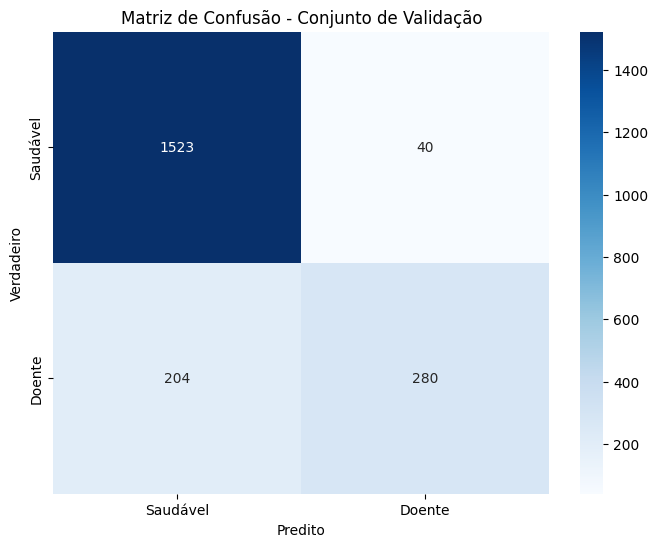

In [20]:
# Matriz de confusão
cm = confusion_matrix(cat_act, cat_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável', 'Doente'],
            yticklabels=['Saudável', 'Doente'])
plt.title('Matriz de Confusão - Conjunto de Validação')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

## Avaliação do modelo

In [21]:
# Avaliar no conjunto de teste
model.eval()
with torch.no_grad():
    y_test_pred = model(test_loader.dataset.tensors[0])
    y_test_actual = test_loader.dataset.tensors[1]

# Converter para classes
if USE_BINARY:
    cat_test_pred = (torch.sigmoid(y_test_pred).squeeze() > 0.5).long().numpy()
    cat_test_actual = y_test_actual.squeeze().long().numpy()

    # Calcular probabilidades
    probs_test = torch.sigmoid(y_test_pred).squeeze().numpy()
    probs_test = np.stack([1-probs_test, probs_test], axis=1)
else:
    # Converter logits para probabilidades (softmax)
    probs_test = torch.nn.functional.softmax(y_test_pred, dim=1).numpy()
    cat_test_pred = torch.argmax(y_test_pred, dim=1).numpy()
    cat_test_actual = torch.argmax(y_test_actual, dim=1).numpy()

# Validar métricas gerais
test_acc = (cat_test_pred == cat_test_actual).sum() / len(cat_test_actual)
print(f"\n{'='*60}")
print("AVALIAÇÃO NO CONJUNTO DE TESTE")
print(f"{'='*60}")
print(f"Acurácia geral: {test_acc:.4f}")


AVALIAÇÃO NO CONJUNTO DE TESTE
Acurácia geral: 0.8969


In [22]:
# Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(cat_test_actual, cat_test_pred,
                          target_names=['Saudável', 'Doente']))


Relatório de Classificação:
              precision    recall  f1-score   support

    Saudável       0.90      0.98      0.94      1564
      Doente       0.90      0.63      0.74       483

    accuracy                           0.90      2047
   macro avg       0.90      0.80      0.84      2047
weighted avg       0.90      0.90      0.89      2047



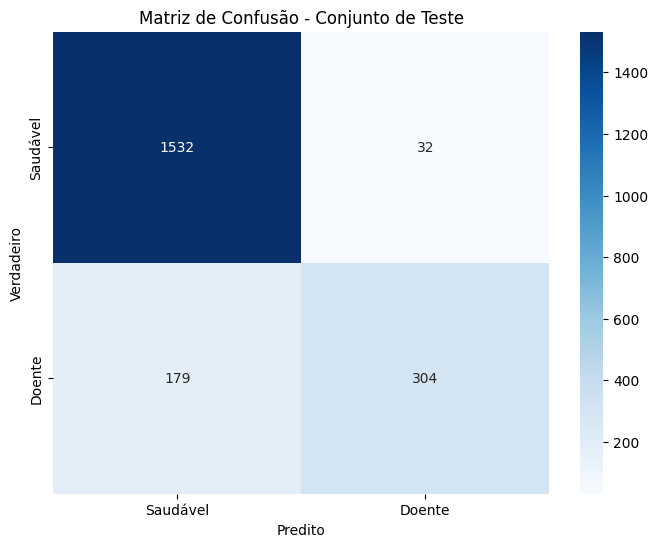

In [23]:
# Matriz de confusão
cm = confusion_matrix(cat_test_actual, cat_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável', 'Doente'],
            yticklabels=['Saudável', 'Doente'])
plt.title('Matriz de Confusão - Conjunto de Teste')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

In [ ]:
uncertainty_threshold = 0.2  # diferença mínima entre as duas classes
max_probs_test = probs_test.max(axis=1)
second_max_probs_test = np.partition(probs_test, -2, axis=1)[:, -2]
prob_diff_test = max_probs_test - second_max_probs_test

# Identificar casos incertos
uncertain_mask_test = prob_diff_test < uncertainty_threshold

# Criar predições com incerteza
cat_test_pred_with_uncertain = cat_test_pred.copy()
cat_test_pred_with_uncertain[uncertain_mask_test] = 2

# Análise de incerteza
print(f"\n{'='*60}")
print("ANÁLISE DE INCERTEZA")
print(f"{'='*60}")
print("Classificações:")
print(f"  Saudável: {(cat_test_pred_with_uncertain == 0).sum()}")
print(f"  Doente: {(cat_test_pred_with_uncertain == 1).sum()}")
print(f"  Incerto: {(cat_test_pred_with_uncertain == 2).sum()}")
print(f"  Total incerto: {uncertain_mask_test.sum()} ({100*uncertain_mask_test.sum()/len(cat_test_pred):.1f}%)")

# Acurácia apenas nos casos certos
certain_mask_test = ~uncertain_mask_test
if certain_mask_test.sum() > 0:
    acc_certain_test = (cat_test_pred[certain_mask_test] == cat_test_actual[certain_mask_test]).sum() / certain_mask_test.sum()
    print(f"\nAcurácia (apenas casos certos): {acc_certain_test:.4f}")
    print(f"Casos descartados: {uncertain_mask_test.sum()} ({100*uncertain_mask_test.sum()/len(cat_test_pred):.1f}%)")

    precision_certain = precision_score(cat_test_actual[certain_mask_test],
                                       cat_test_pred[certain_mask_test],
                                       average='weighted')
    recall_certain = recall_score(cat_test_actual[certain_mask_test],
                                  cat_test_pred[certain_mask_test],
                                  average='weighted')
    f1_certain = f1_score(cat_test_actual[certain_mask_test],
                         cat_test_pred[certain_mask_test],
                         average='weighted')

    print("\nMÉTRICAS (apenas casos certos):")
    print(f"  Precision: {precision_certain:.4f}")
    print(f"  Recall: {recall_certain:.4f}")
    print(f"  F1-Score: {f1_certain:.4f}")

    # Relatório completo
    print(f"\n{'-'*60}")
    print("RELATÓRIO DETALHADO (casos certos):")
    print(f"{'-'*60}")
    print(classification_report(cat_test_actual[certain_mask_test],
                               cat_test_pred[certain_mask_test],
                               target_names=['Saudável', 'Doente']))



ANÁLISE DE INCERTEZA
Classificações:
  Saudável: 1513
  Doente: 218
  Incerto: 316
  Total incerto: 316 (15.4%)

Acurácia (apenas casos certos): 0.9249
Casos descartados: 316 (15.4%)

MÉTRICAS (apenas casos certos):
  Precision: 0.9253
  Recall: 0.9249
  F1-Score: 0.9192

------------------------------------------------------------
RELATÓRIO DETALHADO (casos certos):
------------------------------------------------------------
              precision    recall  f1-score   support

    Saudável       0.92      0.99      0.96      1413
      Doente       0.93      0.64      0.76       318

    accuracy                           0.92      1731
   macro avg       0.93      0.81      0.86      1731
weighted avg       0.93      0.92      0.92      1731

